In [1]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

from utils import alert_training_complete
from utils.dqn_utils import (
    DQN,
    ReplayBuffer,
    load_dqn_checkpoint,
    save_dqn_checkpoint,
    select_greedy_action,
)

In [2]:
env = gym.make("LunarLander-v3")

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

print("State size:", state_size)
print("Action size:", action_size)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

State size: 8
Action size: 4
Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)


In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

Using: cpu


In [4]:
num_episodes = 1500

gamma = 0.99
learning_rate = 5e-4

batch_size = 64

buffer_capacity = 100_000
min_buffer_size = 1_000

epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay_steps = 100_000

target_update_frequency = 1_000

In [5]:
policy_net = DQN(
    state_size,
    action_size
).to(device)

target_net = DQN(
    state_size,
    action_size
).to(device)

target_net.load_state_dict(
    policy_net.state_dict()
)

target_net.eval()

DQN(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [6]:
replay_buffer = ReplayBuffer(
    buffer_capacity
)

optimizer = optim.Adam(
    policy_net.parameters(),
    lr=learning_rate
)

loss_function = nn.SmoothL1Loss()

In [7]:
def get_epsilon(step):

    fraction = min(
        step / epsilon_decay_steps,
        1.0
    )

    epsilon = (
        epsilon_start
        + fraction
        * (epsilon_end - epsilon_start)
    )

    return epsilon

In [8]:
def choose_action(state, epsilon):

    # Exploration
    if np.random.random() < epsilon:
        return env.action_space.sample()

    # Exploitation
    state_tensor = torch.tensor(
        state,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    with torch.no_grad():

        q_values = policy_net(
            state_tensor
        )

    return q_values.argmax(dim=1).item()

In [9]:
def train_dqn():

    if len(replay_buffer) < min_buffer_size:
        return

    (
        states,
        actions,
        rewards,
        next_states,
        terminated
    ) = replay_buffer.sample(
        batch_size,
        device
    )

    # Move batch to GPU/CPU
    states = states.to(device)
    actions = actions.to(device)
    rewards = rewards.to(device)
    next_states = next_states.to(device)
    terminated = terminated.to(device)

    # ------------------------------------------------
    # Current Q(s, a)
    # ------------------------------------------------

    current_q = policy_net(
        states
    ).gather(
        1,
        actions.unsqueeze(1)
    ).squeeze(1)

    # ------------------------------------------------
    # Bellman target
    # ------------------------------------------------

    with torch.no_grad():

        next_q = target_net(
            next_states
        ).max(dim=1).values

        target_q = (
            rewards
            + gamma
            * next_q
            * (1 - terminated)
        )

    # ------------------------------------------------
    # Update policy network
    # ------------------------------------------------

    loss = loss_function(
        current_q,
        target_q
    )

    optimizer.zero_grad()

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        policy_net.parameters(),
        10.0
    )

    optimizer.step()

In [10]:
episode_rewards = []
average_rewards = []

total_steps = 0

for episode in range(num_episodes):

    state, info = env.reset()

    terminated = False
    truncated = False

    episode_reward = 0

    while not (terminated or truncated):

        # --------------------------------------------
        # Choose action
        # --------------------------------------------

        epsilon = get_epsilon(
            total_steps
        )

        action = choose_action(
            state,
            epsilon
        )

        # --------------------------------------------
        # Apply action
        # --------------------------------------------

        (
            next_state,
            reward,
            terminated,
            truncated,
            info
        ) = env.step(action)

        # --------------------------------------------
        # Store experience
        # --------------------------------------------

        replay_buffer.push(
            state,
            action,
            reward,
            next_state,
            terminated
        )

        # --------------------------------------------
        # Train network
        # --------------------------------------------

        train_dqn()

        # --------------------------------------------
        # Update state
        # --------------------------------------------

        state = next_state

        episode_reward += reward
        total_steps += 1

        # --------------------------------------------
        # Update target network
        # --------------------------------------------

        if (
            total_steps
            % target_update_frequency
            == 0
        ):

            target_net.load_state_dict(
                policy_net.state_dict()
            )

    # ------------------------------------------------
    # Episode statistics
    # ------------------------------------------------

    episode_rewards.append(
        episode_reward
    )

    average_reward = np.mean(
        episode_rewards[-100:]
    )

    average_rewards.append(
        average_reward
    )

    # ------------------------------------------------
    # Print progress
    # ------------------------------------------------

    if episode % 100 == 0:

        print(
            f"Episode: {episode:4d} | "
            f"Reward: {episode_reward:8.2f} | "
            f"Average(100): {average_reward:8.2f} | "
            f"Epsilon: {epsilon:.3f}"
        )

    # ------------------------------------------------
    # Solved
    # ------------------------------------------------

    if (
        len(episode_rewards) >= 100
        and average_reward >= 200
    ):

        print(
            f"\nEnvironment solved "
            f"at episode {episode}!"
        )

        break

env.close()

Episode:    0 | Reward:  -147.06 | Average(100):  -147.06 | Epsilon: 0.999
Episode:   25 | Reward:  -161.68 | Average(100):  -168.33 | Epsilon: 0.967
Episode:   50 | Reward:   -65.00 | Average(100):  -157.69 | Epsilon: 0.946
Episode:   75 | Reward:   -80.49 | Average(100):  -149.95 | Epsilon: 0.925
Episode:  100 | Reward:  -115.81 | Average(100):  -146.02 | Epsilon: 0.904
Episode:  125 | Reward:  -118.90 | Average(100):  -137.21 | Epsilon: 0.882
Episode:  150 | Reward:  -136.82 | Average(100):  -130.91 | Epsilon: 0.859
Episode:  175 | Reward:   -58.94 | Average(100):  -123.29 | Epsilon: 0.837
Episode:  200 | Reward:   -99.12 | Average(100):  -115.64 | Epsilon: 0.814
Episode:  225 | Reward:  -100.36 | Average(100):  -100.18 | Epsilon: 0.790
Episode:  250 | Reward:    -2.24 | Average(100):   -89.44 | Epsilon: 0.765
Episode:  275 | Reward:   -88.26 | Average(100):   -84.31 | Epsilon: 0.740
Episode:  300 | Reward:  -121.77 | Average(100):   -75.23 | Epsilon: 0.714
Episode:  325 | Reward:  

In [11]:
# Notify the user only after the complete training loop has finished.
alert_training_complete(
    "Training finished - the LunarLander DQN is ready."
)

Training finished - the LunarLander DQN is ready.


In [17]:
from pathlib import Path

model_path = Path("models") / "lunarlander_dqn.pth"
model_path.parent.mkdir(parents=True, exist_ok=True)

save_dqn_checkpoint(
    model_path,
    policy_net,
    target_net=target_net,
    optimizer=optimizer,
    metadata={
        "episodes": len(episode_rewards),
        "gamma": gamma,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "epsilon_start": epsilon_start,
        "epsilon_end": epsilon_end,
        "epsilon_decay_steps": epsilon_decay_steps,
        "target_update_frequency": target_update_frequency,
        "hidden_sizes": (128, 128),
        "environment": "LunarLander-v3",
        "total_steps": total_steps,
        "average_rewards": average_rewards,
        "episode_rewards": episode_rewards
    },
)

print(f"Saved trained DQN model to: {model_path}")

Saved trained DQN model to: models\lunarlander_dqn.pth


## Load the saved checkpoint

Reload the saved policy network and checkpoint metadata from disk. The helper reads `hidden_sizes` from the checkpoint, reconstructs the matching DQN architecture, moves it to `device`, loads its weights, and switches it to evaluation mode.

In [10]:
from pathlib import Path

model_path = Path("models") / "lunarlander_dqn.pth"

policy_net, checkpoint = load_dqn_checkpoint(
    model_path,
    state_dim=state_size,
    action_dim=action_size,
    device=device,
)

print("Loaded LunarLander DQN checkpoint")
print("Path:", model_path)
print("Environment:", checkpoint["environment"])
print("Training episodes:", checkpoint["episodes"])
print("Total training steps:", checkpoint["total_steps"])
print("Hidden sizes:", checkpoint["hidden_sizes"])
print("Device:", device)

Loaded LunarLander DQN checkpoint
Path: models\lunarlander_dqn.pth
Environment: LunarLander-v3
Training episodes: 711
Total training steps: 158744
Hidden sizes: (128, 128)
Device: cpu


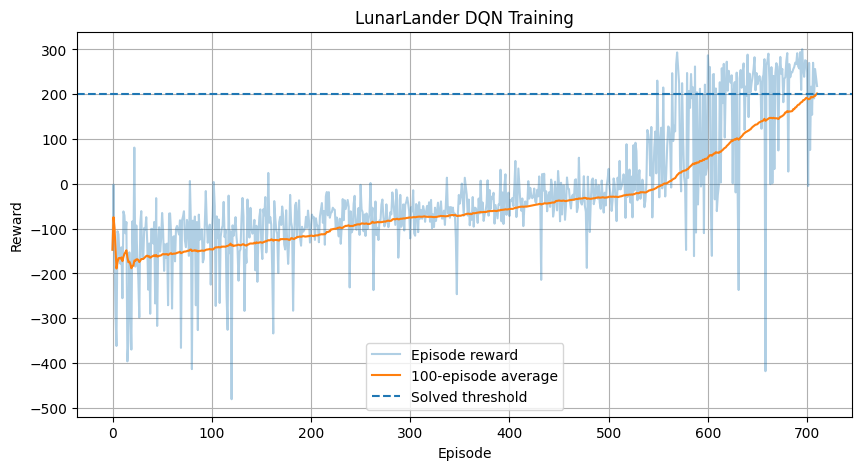

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    checkpoint["episode_rewards"],
    alpha=0.35,
    label="Episode reward"
)

plt.plot(
    checkpoint["average_rewards"],
    label="100-episode average"
)

plt.axhline(
    200,
    linestyle="--",
    label="Solved threshold"
)

plt.xlabel("Episode")
plt.ylabel("Reward")

plt.title(
    "LunarLander DQN Training"
)

plt.legend()
plt.grid()

plt.show()

In [ ]:
test_env = gym.make(
    "LunarLander-v3",
    render_mode="human"
)

num_test_episodes = 10

for episode in range(num_test_episodes):

    state, info = test_env.reset()

    terminated = False
    truncated = False

    total_reward = 0

    while not (terminated or truncated):

        state_tensor = torch.tensor(
            state,
            dtype=torch.float32,
            device=device
        ).unsqueeze(0)

        with torch.no_grad():

            q_values = policy_net(
                state_tensor
            )

            action = q_values.argmax(
                dim=1
            ).item()

        (
            state,
            reward,
            terminated,
            truncated,
            info
        ) = test_env.step(action)

        total_reward += reward

    print(
        f"Test episode {episode + 1}: "
        f"{total_reward:.2f}"
    )

test_env.close()

## Quantitative evaluation over 100 episodes

Evaluate the trained policy without exploration or rendering. Fixed, distinct reset seeds make the result reproducible while still testing 100 different initial conditions. A reward of 200 or more is reported as a high-scoring episode; the primary LunarLander-v3 solved criterion is an average reward of at least 200 over 100 consecutive episodes.

In [12]:
num_evaluation_episodes = 100
evaluation_env = gym.make("LunarLander-v3")
policy_net.eval()
evaluation_rewards = []
evaluation_episode_lengths = []

for evaluation_episode in range(num_evaluation_episodes):
    state, info = evaluation_env.reset(
        seed=10_000 + evaluation_episode
    )
    terminated = False
    truncated = False
    episode_reward = 0.0
    episode_steps = 0

    while not (terminated or truncated):
        # Pure greedy evaluation: epsilon = 0.
        action = select_greedy_action(
            policy_net,
            state,
            device,
        )

        state, reward, terminated, truncated, info = (
            evaluation_env.step(action)
        )
        episode_reward += reward
        episode_steps += 1

    evaluation_rewards.append(episode_reward)
    evaluation_episode_lengths.append(episode_steps)

evaluation_env.close()

evaluation_rewards = np.asarray(evaluation_rewards, dtype=float)
evaluation_episode_lengths = np.asarray(
    evaluation_episode_lengths, dtype=int
)
mean_evaluation_reward = np.mean(evaluation_rewards)
high_score_rate = np.mean(evaluation_rewards >= 200.0)

print("Greedy DQN evaluation (epsilon = 0)")
print("Evaluation episodes:", num_evaluation_episodes)
print(f"Mean reward: {mean_evaluation_reward:.2f}")
print(f"Reward standard deviation: {np.std(evaluation_rewards):.2f}")
print(f"Median reward: {np.median(evaluation_rewards):.2f}")
print(f"Minimum reward: {np.min(evaluation_rewards):.2f}")
print(f"Maximum reward: {np.max(evaluation_rewards):.2f}")
print(
    f"Average episode length: "
    f"{np.mean(evaluation_episode_lengths):.2f}"
)
print(f"Episodes with reward >= 200: {high_score_rate:.1%}")
print("Solved over evaluation set:", mean_evaluation_reward >= 200.0)

Greedy DQN evaluation (epsilon = 0)
Evaluation episodes: 100
Mean reward: 222.06
Reward standard deviation: 55.80
Median reward: 230.00
Minimum reward: -28.94
Maximum reward: 300.83
Average episode length: 472.03
Episodes with reward >= 200: 82.0%
Solved over evaluation set: True


In [14]:
safe_landings = 0
pad_landings = 0

num_test_episodes = 100
test_env = gym.make(
    "LunarLander-v3",
)
for episode in range(num_test_episodes):

    state, info = test_env.reset()

    terminated = False
    truncated = False

    while not (terminated or truncated):

        state_tensor = torch.tensor(
            state,
            dtype=torch.float32,
            device=device
        ).unsqueeze(0)

        with torch.no_grad():
            q_values = policy_net(state_tensor)
            action = q_values.argmax(dim=1).item()

        state, reward, terminated, truncated, info = \
            test_env.step(action)

    # Stable physical landing
    landed_safely = (
        terminated
        and not test_env.unwrapped.game_over
        and not test_env.unwrapped.lander.awake
    )

    if landed_safely:
        safe_landings += 1

        # State[0] is normalized horizontal position
        x_position = state[0]

        # Roughly centered on the pad
        if abs(x_position) < 0.2:
            pad_landings += 1

In [15]:
safe_landing_rate = (
    safe_landings / num_test_episodes * 100
)

pad_landing_rate = (
    pad_landings / num_test_episodes * 100
)

print(
    f"Safe landing rate: "
    f"{safe_landing_rate:.2f}%"
)

print(
    f"Landing-pad rate: "
    f"{pad_landing_rate:.2f}%"
)

Safe landing rate: 86.00%
Landing-pad rate: 84.00%


In [16]:
safe_pad_landings = 0
safe_off_pad_landings = 0
crashes = 0
out_of_bounds = 0
timeouts = 0

for episode in range(num_test_episodes):

    state, info = test_env.reset()

    terminated = False
    truncated = False

    while not (terminated or truncated):

        state_tensor = torch.tensor(
            state,
            dtype=torch.float32,
            device=device
        ).unsqueeze(0)

        with torch.no_grad():
            action = policy_net(
                state_tensor
            ).argmax(dim=1).item()

        state, reward, terminated, truncated, info = \
            test_env.step(action)

    # -----------------------------------------
    # Classify outcome
    # -----------------------------------------

    if truncated:

        timeouts += 1

    elif test_env.unwrapped.game_over:

        crashes += 1

    elif abs(state[0]) >= 1.0:

        out_of_bounds += 1

    elif not test_env.unwrapped.lander.awake:

        if abs(state[0]) < 0.2:
            safe_pad_landings += 1
        else:
            safe_off_pad_landings += 1

In [17]:
print("Safe pad landings:", safe_pad_landings)
print("Safe off-pad landings:", safe_off_pad_landings)
print("Crashes:", crashes)
print("Out of bounds:", out_of_bounds)
print("Timeouts:", timeouts)

Safe pad landings: 84
Safe off-pad landings: 4
Crashes: 0
Out of bounds: 0
Timeouts: 12
